<a href="https://colab.research.google.com/github/ZelentsovTymofii/Data-Science-For-Beginners/blob/main/1-Introduction/04-stats-and-probability/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Probability and Statistics
## Assignment

In this assignment, we will use the dataset of diabetes patients taken [from here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("/content/diabetes.tsv",sep='\t')
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135



In this dataset, columns as the following:
* Age and sex are self-explanatory
* BMI is body mass index
* BP is average blood pressure
* S1 through S6 are different blood measurements
* Y is the qualitative measure of disease progression over one year

Let's study this dataset using methods of probability and statistics.

### Task 1: Compute mean values and variance for all values

In [3]:
mean = df.mean()
var = df.var()


### Task 2: Plot boxplots for BMI, BP and Y depending on gender

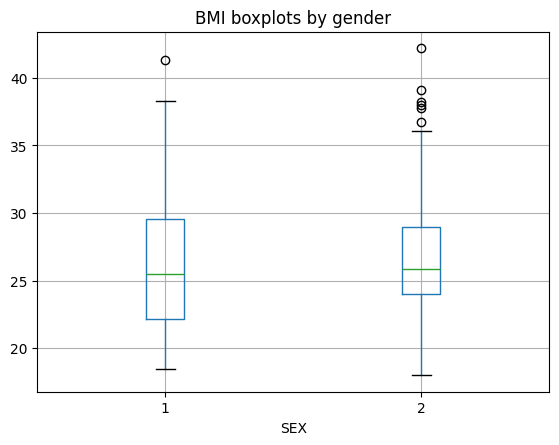

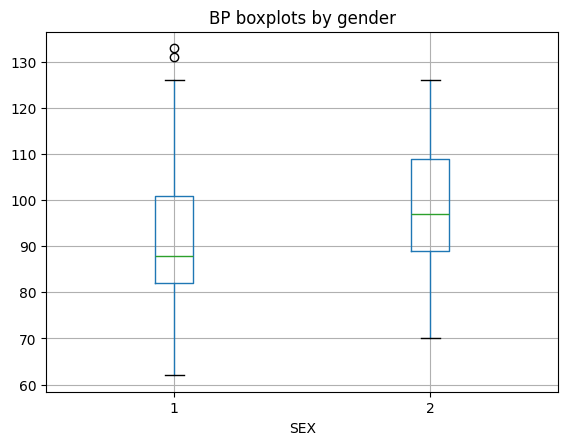

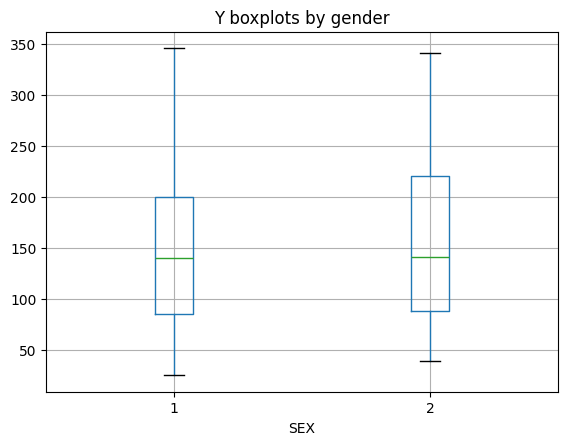

In [9]:
for col in ['BMI', 'BP', 'Y']:
  df.boxplot(column=col,by='SEX')
  plt.title(f'{col} boxplots by gender')
  plt.suptitle('')



### Task 3: What is the the distribution of Age, Sex, BMI and Y variables?

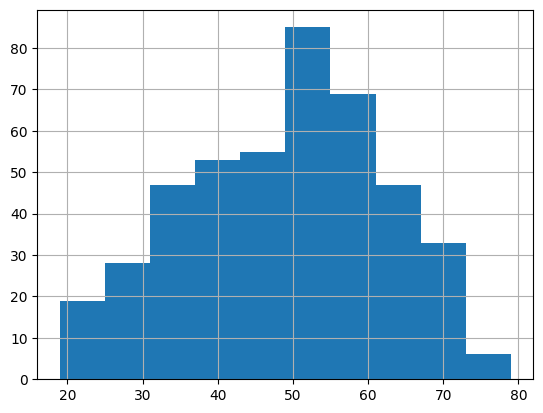

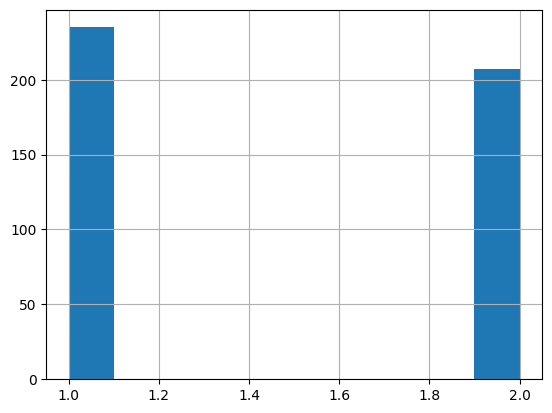

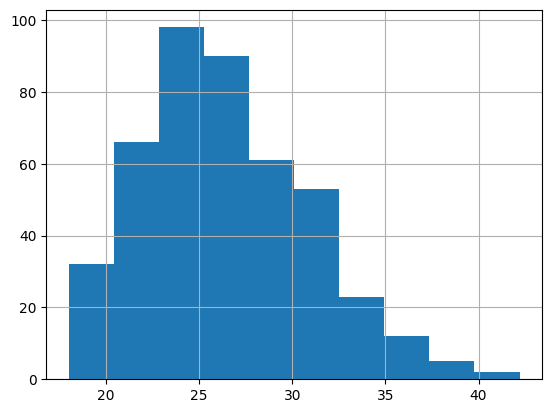

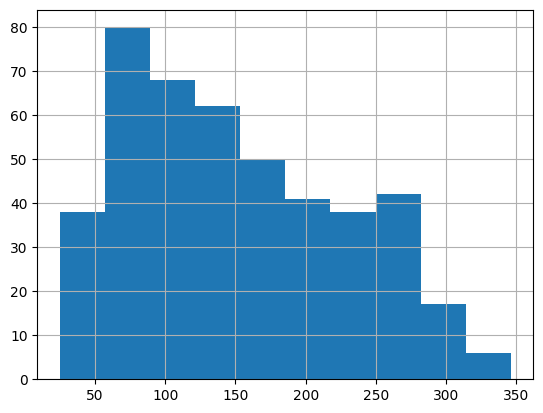

In [15]:
for col in ['AGE','SEX','BMI','Y']:
  df[col].hist()
  plt.show()

### Task 4: Test the correlation between different variables and disease progression (Y)

> **Hint** Correlation matrix would give you the most useful information on which values are dependent.

In [27]:
for item in ['SEX','BMI',"BP","S1","S2",'S3','S4','S5','S6']:
  new_df = df[[item,'Y']]
  print(new_df.corr(method='pearson'))

df.corr()

          SEX         Y
SEX  1.000000  0.043062
Y    0.043062  1.000000
         BMI        Y
BMI  1.00000  0.58645
Y    0.58645  1.00000
          BP         Y
BP  1.000000  0.441482
Y   0.441482  1.000000
          S1         Y
S1  1.000000  0.212022
Y   0.212022  1.000000
          S2         Y
S2  1.000000  0.174054
Y   0.174054  1.000000
          S3         Y
S3  1.000000 -0.394789
Y  -0.394789  1.000000
          S4         Y
S4  1.000000  0.430453
Y   0.430453  1.000000
          S5         Y
S5  1.000000  0.565883
Y   0.565883  1.000000
          S6         Y
S6  1.000000  0.382483
Y   0.382483  1.000000


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
AGE,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
SEX,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
BMI,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
BP,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
S1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
S2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
S3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
S4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
S5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
S6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


### Task 5: Test the hypothesis that the degree of diabetes progression is different between men and women

In [29]:
from scipy.stats import ttest_ind
t_val, p_val = ttest_ind(df.loc[df['SEX']==1,['Y']], df.loc[df['SEX']==2,['Y']])
print(f'T-Value = {t_val[0]:.2f}, P-Value = {p_val[0]}')

T-Value = -0.90, P-Value = 0.3664292946519826
